In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.api as sm
import matplotlib.pyplot as plt

import os
os.getcwd()
os.chdir("/Users/xiaolingsundberg/Desktop/Other Data Analysis Projects (for fun)/CovidOnLottery/Data")

In [4]:
# read the data
df = pd.read_stata("megamillions_revenues.dta")

# Sanity Check

In [75]:
# check first and last 5 rows, data shape, column names, data type. 
print(df.head())
print(df.columns)
print(df.shape)
print(df.dtypes)
print(df.tail())

   draw_date  revenues  jackpot  covid  covid_cases  tuesday  unempr_adjusted  \
0 2016-05-03   1456844      128      0            0        1              4.9   
1 2016-05-06   1493001      138      0            0        0              4.9   
2 2016-05-10   1609441      150      0            0        1              4.9   
3 2016-05-13   1605501      161      0            0        0              4.9   
4 2016-05-17   1659294      174      0            0        1              4.9   

   unempr  jan  feb  ...  sept  oct  nov  year2016  year2017  year2018  \
0     4.6    0    0  ...     0    0    0         1         0         0   
1     4.6    0    0  ...     0    0    0         1         0         0   
2     4.6    0    0  ...     0    0    0         1         0         0   
3     4.6    0    0  ...     0    0    0         1         0         0   
4     4.6    0    0  ...     0    0    0         1         0         0   

   year2019  year2020  year2021  year2022  
0         0         0   

In [76]:
# check missing values 
print(df.isnull().sum())

draw_date          0
revenues           0
jackpot            0
covid              0
covid_cases        0
tuesday            0
unempr_adjusted    0
unempr             0
jan                0
feb                0
mar                0
apr                0
may                0
jun                0
jul                0
aug                0
sept               0
oct                0
nov                0
year2016           0
year2017           0
year2018           0
year2019           0
year2020           0
year2021           0
year2022           0
dtype: int64


# Data Exploration
## Summary Statistics and Visualization

In [77]:
# summary statistics
print(df.describe())

                           draw_date      revenues      jackpot       covid  \
count                            610  6.100000e+02   610.000000  610.000000   
mean   2019-04-03 11:24:35.409836032  2.555597e+06   153.226230    0.344262   
min              2016-05-03 00:00:00  5.216690e+05    15.000000    0.000000   
25%              2017-10-17 18:00:00  1.553919e+06    51.250000    0.000000   
50%              2019-04-03 12:00:00  1.911706e+06   106.000000    0.000000   
75%              2020-09-17 06:00:00  2.481830e+06   210.250000    1.000000   
max              2022-03-04 00:00:00  6.034521e+07  1600.000000    1.000000   
std                              NaN  3.631296e+06   148.222954    0.475517   

        covid_cases    tuesday  unempr_adjusted      unempr         jan  \
count    610.000000  610.00000       610.000000  610.000000  610.000000   
mean    2854.563934    0.50000         4.780328    4.772459    0.086885   
min        0.000000    0.00000         2.700000    2.500000    

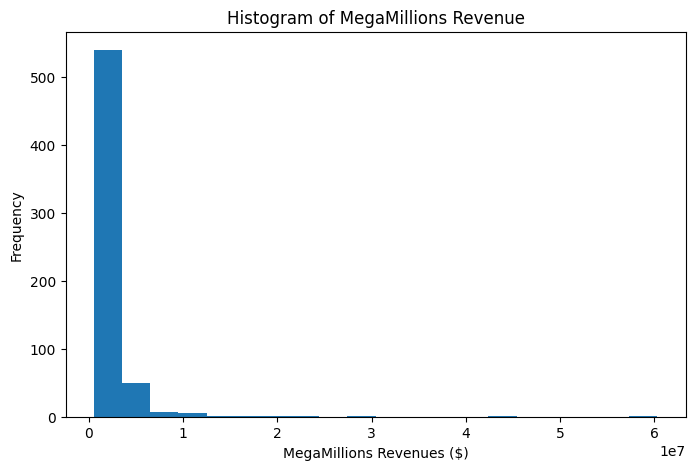

In [78]:
# histogram of overall revenue distribution

plt.figure(figsize=(8, 5))
plt.hist(df["revenues"], bins=20)
plt.xlabel("MegaMillions Revenues ($)")
plt.ylabel("Frequency")
plt.title("Histogram of MegaMillions Revenue")
plt.show()

Conclusion: The megamillion revenues distribution is heavily right-skewed with most observations concentrated in the lower revenue range roughly between $1.0 million and $3.0 million and there are a few much larger values that create a long right tail. A log transformation may be considered.

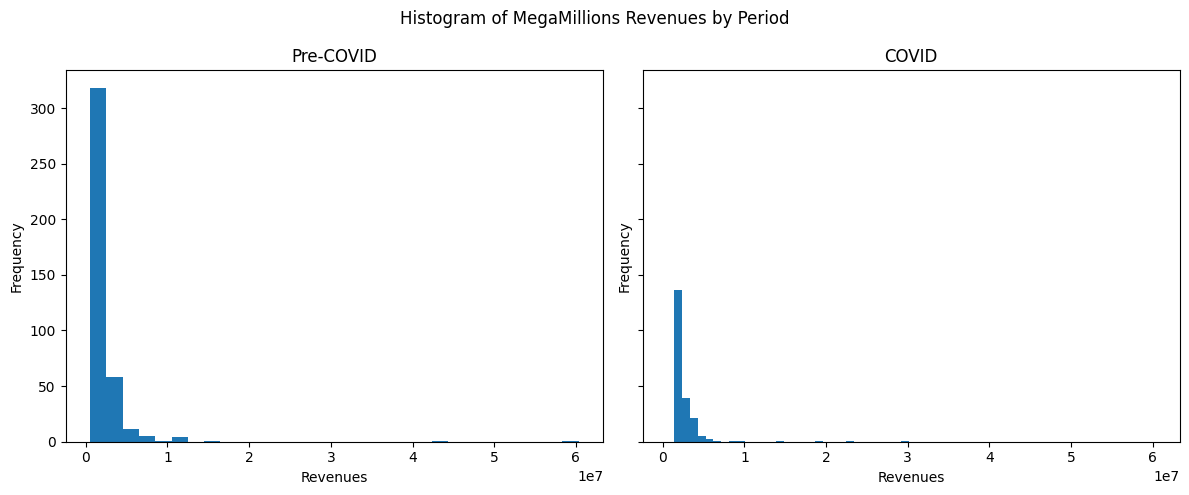

In [79]:
# histogram of revenues by period
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-COVID
axes[0].hist(df.loc[df["covid"] == 0, "revenues"], bins=30)
axes[0].set_title("Pre-COVID")
axes[0].set_xlabel("Revenues")
axes[0].set_ylabel("Frequency")

# COVID
axes[1].hist(df.loc[df["covid"] == 1, "revenues"], bins=30)
axes[1].set_title("COVID")
axes[1].set_xlabel("Revenues")
axes[1].set_ylabel("Frequency")

plt.suptitle("Histogram of MegaMillions Revenues by Period")
plt.tight_layout()
plt.show()

Revenues in both periods appear to be right skewed. 

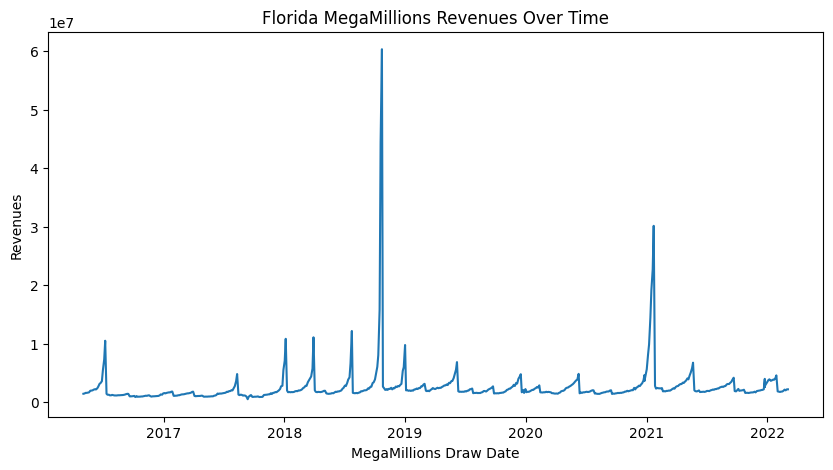

In [80]:
# line plot of revenues over time
plt.figure(figsize=(10, 5))
plt.plot(df["draw_date"], df["revenues"])
plt.xlabel("MegaMillions Draw Date")
plt.ylabel("Revenues")
plt.title("Florida MegaMillions Revenues Over Time")
plt.show()

Conclusion: The line plot suggests a noticeable decline in Florida MegaMillions revenues around the beginning of the COVID period, especially in 2020, followed by partial recovery afterward. The series is also characterized by several sharp spikes, including one extreme outlier around late 2018 to early 2019 exceeding $60 million.

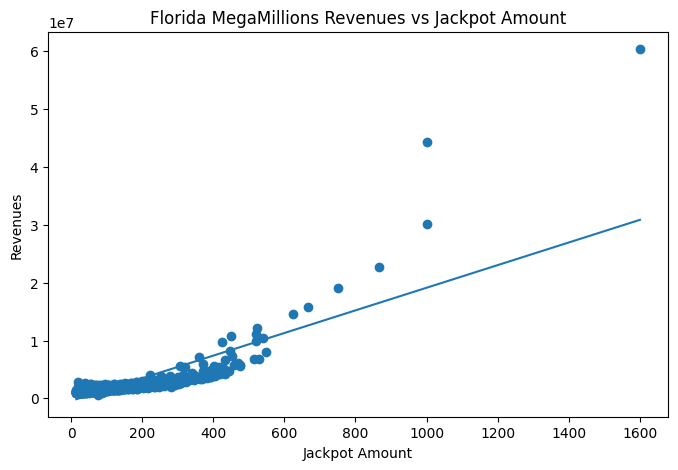

In [81]:
# scatter plot of revenues vs jackpot
plt.figure(figsize=(8, 5))
plt.scatter(df["jackpot"], df["revenues"])

slope_all, intercept_all = np.polyfit(df["jackpot"], df["revenues"], 1)
x_sorted = np.sort(df["jackpot"])
plt.plot(x_sorted, slope_all * x_sorted + intercept_all)

plt.xlabel("Jackpot Amount")
plt.ylabel("Revenues")
plt.title("Florida MegaMillions Revenues vs Jackpot Amount")
plt.show()

Conclusion: The plot suggests a positive relationship between Florida MegaMillions revenues and jackpot amount. Higher jackpot amounts are generally associated with higher revenues, although the relationship is influenced by a few large outliers.

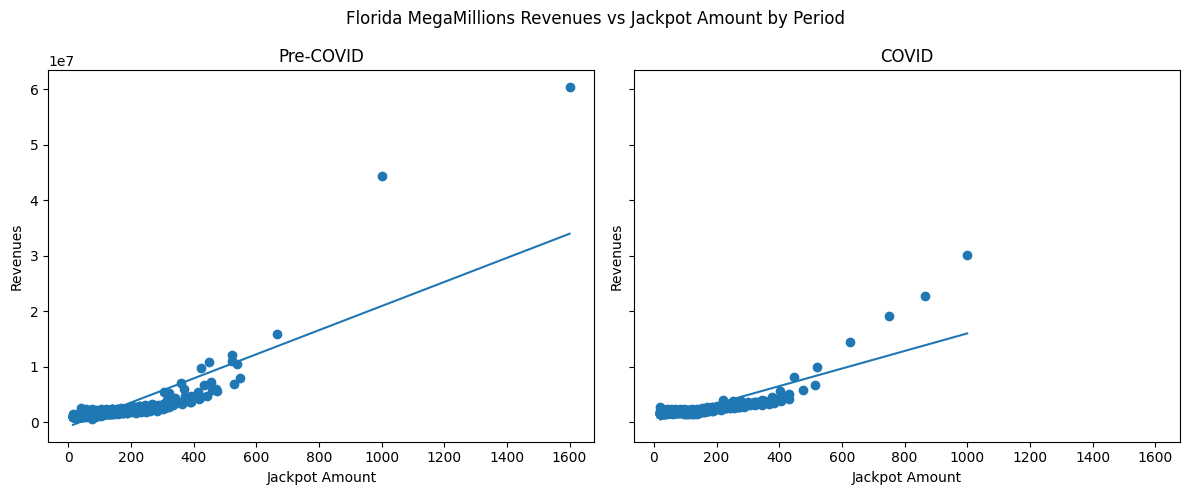

In [82]:
# scatter plots by period with same scales
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-COVID
x_pre = df.loc[df["covid"] == 0, "jackpot"]
y_pre = df.loc[df["covid"] == 0, "revenues"]

axes[0].scatter(x_pre, y_pre)
slope_pre, intercept_pre = np.polyfit(x_pre, y_pre, 1)
x_pre_sorted = np.sort(x_pre)
axes[0].plot(x_pre_sorted, slope_pre * x_pre_sorted + intercept_pre)
axes[0].set_title("Pre-COVID")
axes[0].set_xlabel("Jackpot Amount")
axes[0].set_ylabel("Revenues")

# COVID
x_covid = df.loc[df["covid"] == 1, "jackpot"]
y_covid = df.loc[df["covid"] == 1, "revenues"]

axes[1].scatter(x_covid, y_covid)
slope_covid, intercept_covid = np.polyfit(x_covid, y_covid, 1)
x_covid_sorted = np.sort(x_covid)
axes[1].plot(x_covid_sorted, slope_covid * x_covid_sorted + intercept_covid)
axes[1].set_title("COVID")
axes[1].set_xlabel("Jackpot Amount")
axes[1].set_ylabel("Revenues")

plt.suptitle("Florida MegaMillions Revenues vs Jackpot Amount by Period")
plt.tight_layout()
plt.show()

Conclusion: The scatter plots suggest a positive relationship between Florida MegaMillions revenues and jackpot amount in both periods. In both the pre-COVID and COVID periods, higher jackpot amounts are generally associated with higher revenues. However, the fitted line appears steeper in the pre-COVID period, suggesting that revenues may have been more responsive to jackpot increases before COVID. The plots also show substantial variability and a few large outliers, especially in the pre-COVID period, so the relationship should be interpreted with some caution.

In [83]:
# compare revenues between Pre-covid and Covid periods 
# define Covid period: any time after March 03, 2020 (first case recorded in the United States)
df["covid_period"] = np.where(
    df["draw_date"] >= pd.Timestamp("2020-03-04"),
    1,
    0
)

<Figure size 800x500 with 0 Axes>

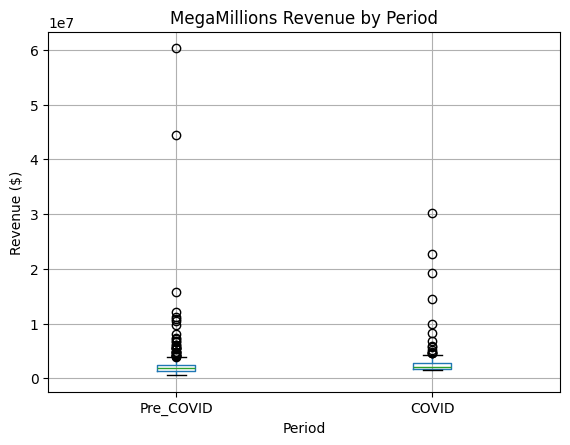

In [84]:
# boxplot by period
df["covid_label"] = pd.Categorical(
    df["covid"].map({0: "Pre_COVID", 1: "COVID"}),
    categories=["Pre_COVID", "COVID"],
    ordered=True
)

plt.figure(figsize=(8, 5))
df.boxplot(column="revenues", by="covid_label")

plt.title("MegaMillions Revenue by Period")
plt.suptitle("")
plt.xlabel("Period")
plt.ylabel("Revenue ($)")
plt.show()

Conclusion: The boxplot suggests that MegaMillions revenues were slightly higher during the COVID period than in the pre-COVID period, as reflected by the somewhat higher center of the COVID distribution. However, both periods show substantial dispersion and many outliers, indicating that revenues were highly variable throughout the sample. The pre-COVID period also appears to contain more extreme high-revenue outliers than the COVID period.

In [85]:
# correlation coefficient tests
# Pearson's p and Spearman Rank Order Correlation 
print("Pearson's Correlation:")
print(df[["jackpot","revenues"]].corr(method="pearson"))

print("Spearman's Correlation:")
print(df[["jackpot","revenues"]].corr(method="spearman"))

Pearson's Correlation:
           jackpot  revenues
jackpot   1.000000  0.798525
revenues  0.798525  1.000000
Spearman's Correlation:
           jackpot  revenues
jackpot   1.000000  0.801648
revenues  0.801648  1.000000


Conclusion: Both the Pearson and Spearman correlations show a strong positive association between revenues and jackpot amount, suggesting that the positive relationship is stable, even though the data still show skewness and outliers.

In [86]:
# summary statistics before and after covid
print("MegaMillions Revenue Before Covid:")
print(df.loc[df["covid"] == 0, ["revenues"]].describe())

print("MegaMillions Revenue During Covid:")
print(df.loc[df["covid"] == 1, ["revenues"]].describe())

MegaMillions Revenue Before Covid:
           revenues
count  4.000000e+02
mean   2.429198e+06
std    3.934426e+06
min    5.216690e+05
25%    1.356318e+06
50%    1.792846e+06
75%    2.371519e+06
max    6.034521e+07
MegaMillions Revenue During Covid:
           revenues
count  2.100000e+02
mean   2.796358e+06
std    2.963492e+06
min    1.424511e+06
25%    1.771515e+06
50%    2.038710e+06
75%    2.773762e+06
max    3.015734e+07


Conclusion: The summary statistics suggest that Florida MegaMillions revenues were slightly higher during COVID than before COVID. Both the mean and median increased during the COVID period, indicating a modest upward shift in typical revenues. However, revenues were more variable before COVID, with a larger standard deviation and much more extreme high-revenue observations.

# Outlier Detection for Revenues
### 3 standard deviation rule 
### Hampel Identifier
### IQR - already done above

In [87]:
# 3 standard deviation rule 
mean_revenue = df["revenues"].mean()
std_revenue = df["revenues"].std()

lower_3std = mean_revenue - 3*std_revenue
upper_3std = mean_revenue + 3*std_revenue

outliers_std = df[(df["revenues"]<lower_3std)|(df["revenues"]>upper_3std)]

print("3 Standard Deviation Rule:")
print("Lower Bound:", lower_3std)
print("Upper Bound:", upper_3std)
print("Number of Outliers", outliers_std.shape[0])

print(outliers_std[["draw_date","jackpot","revenues"]])

3 Standard Deviation Rule:
Lower Bound: -8338290.800513314
Upper Bound: 13449485.67920184
Number of Outliers 7
     draw_date  jackpot  revenues
256 2018-10-16      667  15847261
257 2018-10-19     1000  44387543
258 2018-10-23     1600  60345214
490 2021-01-12      625  14500818
491 2021-01-15      750  19152705
492 2021-01-19      865  22733013
493 2021-01-22     1000  30157335


Conclusion: 7 (rows) out 610 (rows) (approximately = 1.15%) are detected as outliers. This proportion is slightly above the 1% three-std outlier threshold, more robust outlier detection methods are considered: Hampel and IQR.

In [88]:
# hampel identifier 
    ## the hampel use median and MAD is the core part
# MAD:
    ## first calculate the absolute deviation: abs(revenues - median_revenue)
    ## then take the median of those absolute deviations

# Hampel score:
    ## absolute deviation divided by (1.4826 * MAD)
median_revenue = df["revenues"].median()

MAD = np.median(np.abs(df["revenues"]-median_revenue))

hampel_score = np.abs(df["revenues"]-median_revenue)/(1.4826*MAD)

outliers_hampel = df[hampel_score>3]

print("Hample Outliers:")
print("Median:", median_revenue)
print("MAD:", MAD)
print("Number of Outliers:", outliers_hampel.shape[0])

print(outliers_hampel[["draw_date","jackpot","revenues"]])

Hample Outliers:
Median: 1911706.5
MAD: 432007.5
Number of Outliers: 56
     draw_date  jackpot  revenues
17  2016-07-01      415   5469435
18  2016-07-05      454   7341317
19  2016-07-08      540  10516118
133 2017-08-11      393   4823875
173 2017-12-29      306   5508554
174 2018-01-02      361   7111987
175 2018-01-05      450  10846570
196 2018-03-20      377   4119776
197 2018-03-23      421   4412069
198 2018-03-27      458   5769656
199 2018-03-30      521  11102510
229 2018-07-13      340   3877482
230 2018-07-17      375   4263697
231 2018-07-20      433   6644663
232 2018-07-24      522  12186385
252 2018-10-02      367   3910516
253 2018-10-05      420   4824100
254 2018-10-09      470   6056546
255 2018-10-12      548   8059164
256 2018-10-16      667  15847261
257 2018-10-19     1000  44387543
258 2018-10-23     1600  60345214
276 2018-12-25      321   5363613
277 2018-12-28      370   6005186
278 2019-01-01      425   9787930
320 2019-05-28      418   4129982
321 2019-0

In [89]:
# IQR
Q1 = df["revenues"].quantile(0.25)
Q3 = df["revenues"].quantile(0.75)
IQR = Q3-Q1

lower_IQR = Q1 - 1.5*IQR
upper_IQR = Q3 + 1.5*IQR

outliers_IQR = df[(df["revenues"]<lower_IQR)|(df["revenues"]>upper_IQR)]

print("Interquartile Range (IQR) Outliers:")
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_IQR)
print("Upper Bound:", upper_IQR)
print("Number of Outliers:", outliers_IQR.shape[0])

print(outliers_IQR[["draw_date","jackpot","revenues"]])


Interquartile Range (IQR) Outliers:
Q1: 1553919.0
Q3: 2481830.5
IQR: 927911.5
Lower Bound: 162051.75
Upper Bound: 3873697.75
Number of Outliers: 52
     draw_date  jackpot  revenues
17  2016-07-01      415   5469435
18  2016-07-05      454   7341317
19  2016-07-08      540  10516118
133 2017-08-11      393   4823875
173 2017-12-29      306   5508554
174 2018-01-02      361   7111987
175 2018-01-05      450  10846570
196 2018-03-20      377   4119776
197 2018-03-23      421   4412069
198 2018-03-27      458   5769656
199 2018-03-30      521  11102510
229 2018-07-13      340   3877482
230 2018-07-17      375   4263697
231 2018-07-20      433   6644663
232 2018-07-24      522  12186385
252 2018-10-02      367   3910516
253 2018-10-05      420   4824100
254 2018-10-09      470   6056546
255 2018-10-12      548   8059164
256 2018-10-16      667  15847261
257 2018-10-19     1000  44387543
258 2018-10-23     1600  60345214
276 2018-12-25      321   5363613
277 2018-12-28      370   6005186
27

Conclusion: Hampel and IQR detect a similar number of outliers (56 and 52, respectively), and both identify substantially more outliers than the 3-standard-deviation method (7). Given that the data distribution is heavily right-skewed, this suggests that the 3-standard-deviation method may be overly influenced by the mean and standard deviation. Therefore, a more robust modeling approach is preferred when building the regression model.

# Preparation for Building Regression Models
### Create new variables (lagjackpot, interaction terms)

In [5]:
# note: in the first analysis (PowerBall revenues), the correlation between the unemployment
# rate variable (unempr) and the adjusted unemployment rate variable (unempr_adjusted) was examined.
# The results showed that the two variables were almost perfectly correlated, so only the
# unemployment rate variable (unempr) was retained in the model. The same applies here because
# the same variables are used. Therefore, that correlation check is not repeated in this analysis.
    ## check the correlation of variables to avoid multicollinearity 
    ## print("Correlation Between Unemployment Rate and Adjusted Unemployment Rate")
    ## print(df[["unempr_adjusted","unempr"]].corr())

# make sure draw_date is datetime
df["draw_date"] = pd.to_datetime(df["draw_date"])

# lagged jackpot
df["lagjackpot"] = df["jackpot"].shift(1)

# use log transformation to reduce the skewness of the data
df["log_revenue"] = np.log(df["revenues"])

# interaction terms
df["lagjackpot_covid"] = df["lagjackpot"] * df["covid"]
df["unempr_covid"] = df["unempr"] * df["covid"]
df["lagjackpot_unempr"] = df["lagjackpot"] * df["unempr"]

# Build Three Regression Models
#### Model 1: revenues = covid + lagjackpot + unempr + tuesday
#### Model 2: revenues = covid + lagjackpot + lagjackpot_covid + unempr + unempr_covid + tuesday
#### Model 3: revenues = covid + lagjackpot + lagjackpot_covid + unempr + unempr_covid + lagjackpot_unempr + tuesday

In [7]:
# use one common dataset for all model comparisons

all_model_vars = [
    "log_revenue",
    "covid",
    "lagjackpot",
    "lagjackpot_covid",
    "unempr",
    "unempr_covid",
    "lagjackpot_unempr",
    "tuesday"
]

df_compare = df[all_model_vars].dropna().copy()

print(df_compare.shape)

(609, 8)


In [8]:
# Model 1
# revenues = covid + lagjackpot + unempr + tuesday

X1 = df_compare[["covid", "lagjackpot", "unempr", "tuesday"]]
X1 = sm.add_constant(X1)
y = df_compare["log_revenue"]

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     213.2
Date:                Mon, 30 Mar 2026   Prob (F-statistic):          5.96e-114
Time:                        18:58:02   Log-Likelihood:                -201.53
No. Observations:                 609   AIC:                             413.1
Df Residuals:                     604   BIC:                             435.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.1958      0.038    377.373      0.0

In [9]:
# Model 2

X2 = df_compare[["covid", "lagjackpot", "lagjackpot_covid", "unempr", "unempr_covid", "tuesday"]]
X2 = sm.add_constant(X2)
y = df_compare["log_revenue"]

model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     166.6
Date:                Mon, 30 Mar 2026   Prob (F-statistic):          2.25e-124
Time:                        18:58:29   Log-Likelihood:                -171.70
No. Observations:                 609   AIC:                             357.4
Df Residuals:                     602   BIC:                             388.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               14.8802      0.097  

In [10]:
# Model 3
X3 = df_compare[["covid", "lagjackpot", "lagjackpot_covid", "unempr", "unempr_covid", "lagjackpot_unempr", "tuesday"]]
X3 = sm.add_constant(X3)
y = df_compare["log_revenue"]

model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     144.4
Date:                Mon, 30 Mar 2026   Prob (F-statistic):          2.58e-124
Time:                        18:58:37   Log-Likelihood:                -169.19
No. Observations:                 609   AIC:                             354.4
Df Residuals:                     601   BIC:                             389.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                14.9528      0.10

# Compare the models 
### AIC, BIC, Adjusted-R^2

In [11]:
comparison_table = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "n_obs": [model1.nobs, model2.nobs, model3.nobs],
    "R_squared": [model1.rsquared, model2.rsquared, model3.rsquared],
    "Adj_R_squared": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    "AIC": [model1.aic, model2.aic, model3.aic],
    "BIC": [model1.bic, model2.bic, model3.bic]
})

comparison_table

,Model,n_obs,R_squared,Adj_R_squared,AIC,BIC
0,Model 1,609.0,0.585395,0.582650,413.064878,435.123969
1,Model 2,609.0,0.624093,0.620347,357.392207,388.274935
2,Model 3,609.0,0.627177,0.622835,354.375667,389.670213


Conclusion: Among the three candidate models, Model 3 achieved the highest adjusted R-squared and the lowest AIC, indicating the best overall fit. Although Model 1 had the lowest BIC and is therefore the most parsimonious specification, Model 3 was selected as the final model because it provides the strongest fit to the data.

# Post-estimation inference for the final model

In [12]:
def linear_combination_test(results, weights_dict, label="Quantity"):
    parameter_names = results.params.index
    weight_vector = pd.Series(0.0, index=parameter_names)

    for name, weight in weights_dict.items():
        weight_vector[name] = weight

    test_result = results.t_test(weight_vector.values)

    estimate = test_result.effect.item()
    standard_error = test_result.sd.item()
    t_value = test_result.tvalue.item()
    p_value = test_result.pvalue.item()
    ci_lower, ci_upper = test_result.conf_int()[0]

    output = pd.DataFrame({
        "Quantity": [label],
        "Estimate": [estimate],
        "Std_Error": [standard_error],
        "t_value": [t_value],
        "p_value": [p_value],
        "CI_Lower_95": [ci_lower],
        "CI_Upper_95": [ci_upper]
    })

    return output

# sample means used in Model 3 interpretation
mean_jackpot_3 = df_compare["lagjackpot"].mean()
mean_unempr_3 = df_compare["unempr"].mean()
mean_lagjackpot_unempr_3 = df_compare["lagjackpot_unempr"].mean()
mean_tuesday_3 = df_compare["tuesday"].mean()

# 1) predicted mean revenue before COVID

predicted_mean_before_weights = {
    "const": 1,
    "lagjackpot": mean_jackpot_3,
    "unempr": mean_unempr_3,
    "lagjackpot_unempr": mean_lagjackpot_unempr_3,
    "tuesday": mean_tuesday_3
}

predicted_mean_before_result = linear_combination_test(
    model3,
    predicted_mean_before_weights,
    label="Predicted mean revenue before COVID"
)

# 2) predicted mean revenue during COVID
predicted_mean_during_weights = {
    "const": 1,
    "covid": 1,
    "lagjackpot": mean_jackpot_3,
    "lagjackpot_covid": mean_jackpot_3,
    "unempr": mean_unempr_3,
    "unempr_covid": mean_unempr_3,
    "lagjackpot_unempr": mean_lagjackpot_unempr_3,
    "tuesday": mean_tuesday_3
}

predicted_mean_during_result = linear_combination_test(
    model3,
    predicted_mean_during_weights,
    label="Predicted mean revenue during COVID"
)

# 3) difference in predicted mean revenue
difference_in_predicted_mean_weights = {
    "covid": 1,
    "lagjackpot_covid": mean_jackpot_3,
    "unempr_covid": mean_unempr_3
}

difference_in_predicted_mean_result = linear_combination_test(
    model3,
    difference_in_predicted_mean_weights,
    label="Difference in predicted mean revenue (during - before)"
)

# 4) mean marginal effect of lagjackpot before COVID
marginal_effect_lagjackpot_before_weights = {
    "lagjackpot": 1,
    "lagjackpot_unempr": mean_unempr_3
}

marginal_effect_lagjackpot_before_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_before_weights,
    label="Mean marginal effect of lagjackpot before COVID"
)

# 5) mean marginal effect of lagjackpot during COVID
marginal_effect_lagjackpot_during_weights = {
    "lagjackpot": 1,
    "lagjackpot_covid": 1,
    "lagjackpot_unempr": mean_unempr_3
}

marginal_effect_lagjackpot_during_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_during_weights,
    label="Mean marginal effect of lagjackpot during COVID"
)

# 6) difference in mean marginal effect of lagjackpot
difference_in_marginal_effect_lagjackpot_weights = {
    "lagjackpot_covid": 1
}

difference_in_marginal_effect_lagjackpot_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_lagjackpot_weights,
    label="Difference in mean marginal effect of lagjackpot"
)

# 7) mean marginal effect of unempr before COVID
marginal_effect_unempr_before_weights = {
    "unempr": 1,
    "lagjackpot_unempr": mean_jackpot_3
}

marginal_effect_unempr_before_result = linear_combination_test(
    model3,
    marginal_effect_unempr_before_weights,
    label="Mean marginal effect of unempr before COVID"
)

# 8) mean marginal effect of unempr during COVID
marginal_effect_unempr_during_weights = {
    "unempr": 1,
    "unempr_covid": 1,
    "lagjackpot_unempr": mean_jackpot_3
}

marginal_effect_unempr_during_result = linear_combination_test(
    model3,
    marginal_effect_unempr_during_weights,
    label="Mean marginal effect of unempr during COVID"
)

# 9) difference in mean marginal effect of unempr
difference_in_marginal_effect_unempr_weights = {
    "unempr_covid": 1
}

difference_in_marginal_effect_unempr_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_unempr_weights,
    label="Difference in mean marginal effect of unempr"
)

# combine all post-estimation results
model3_post_estimation_table = pd.concat([
    predicted_mean_before_result,
    predicted_mean_during_result,
    difference_in_predicted_mean_result,
    marginal_effect_lagjackpot_before_result,
    marginal_effect_lagjackpot_during_result,
    difference_in_marginal_effect_lagjackpot_result,
    marginal_effect_unempr_before_result,
    marginal_effect_unempr_during_result,
    difference_in_marginal_effect_unempr_result
], ignore_index=True)

model3_post_estimation_table

,Quantity,Estimate,Std_Error,t_value,p_value,CI_Lower_95,CI_Upper_95
0,Predicted mean revenue before COVID,14.304996,0.026006,550.075363,0.000000e+00,14.253923,14.356069
1,Predicted mean revenue during COVID,14.674077,0.024981,587.412705,0.000000e+00,14.625017,14.723138
2,Difference in predicted mean revenue (during -...,0.369081,0.036033,10.242836,8.390733e-23,0.298315,0.439848
3,Mean marginal effect of lagjackpot before COVID,0.002673,0.000126,21.239358,4.145931e-75,0.002426,0.002920
4,Mean marginal effect of lagjackpot during COVID,0.002276,0.000165,13.816187,6.645205e-38,0.001952,0.002599
5,Difference in mean marginal effect of lagjackpot,-0.000398,0.000228,-1.744588,8.156787e-02,-0.000845,0.000050
6,Mean marginal effect of unempr before COVID,-0.202269,0.023278,-8.689424,3.451778e-17,-0.247984,-0.156554
7,Mean marginal effect of unempr during COVID,-0.015016,0.006817,-2.202763,2.799030e-02,-0.028404,-0.001628
8,Difference in mean marginal effect of unempr,0.187253,0.024263,7.717560,4.963729e-14,0.139602,0.234904


Conclusion: The post-estimation results for Model 3 suggest that, evaluated at the sample means, average Florida MegaMillions revenue was somewhat higher during the COVID period than before COVID, increasing from about $2.28 million to $2.71 million. However, the estimated difference of about $428,073 per drawing is not statistically significant (p = 0.198).

The results also suggest that the marginal effect of jackpot size was slightly smaller during COVID, while the marginal effect of unemployment became less negative, but neither change is statistically significant. Therefore, the evidence from Model 3 does not provide sufficient statistical support to conclude that Florida MegaMillions revenues or their responsiveness to jackpot size and unemployment changed significantly between the two periods.

These results may reflect some change in aggregate spending behavior during the pandemic, but because this thesis uses state-level aggregate data, it cannot identify individual-level behavioral changes directly.